**Objetivos de la Versión 3**

- Inicializar una Tabla Q
- Elegir acciones usando ε-Greedy
- Actualizar la Tabla Q
- Entrenar durante muchos episodios
- Obtener la política óptima
- Ver la ruta aprendida

**Tabla Q**

| Estado |   ↑ |   ↓ |   ← |   → |
| ------ | --: | --: | --: | --: |
| (0,0)  |   0 |   0 |   0 |   0 |
| (0,1)  |   0 |   0 |   0 |   0 |
| (0,2)  |   0 |   0 |   0 |   0 |
| ...    | ... | ... | ... | ... |


**El algoritmo matemático**

En cada movimiento actualizamos:

Q(s,a) = Q(s,a) + α[r+γmaxQ(s
′
,a
′
) − Q(s,a)]

donde:

α (alpha) = velocidad de aprendizaje.
γ (gamma) = importancia del futuro.
r = recompensa inmediata.


TABLA Q FINAL

Estado (0,0)
   ↑ :    -3.09
   ↓ :    -3.71
   ← :    -3.08
   → :    -2.25

Estado (0,1)
   ↑ :    -2.27
   ↓ :   -10.00
   ← :    -3.06
   → :    -1.39

Estado (0,2)
   ↑ :    -1.42
   ↓ :    -1.06
   ← :    -2.28
   → :    -0.43

Estado (0,3)
   ↑ :    -0.48
   ↓ :    -9.97
   ← :    -1.41
   → :     0.63

Estado (0,4)
   ↑ :     0.55
   ↓ :     1.81
   ← :    -0.51
   → :     1.30

Estado (0,5)
   ↑ :    -1.16
   ↓ :     2.99
   ← :    -0.94
   → :    -1.18

Estado (1,0)
   ↑ :    -3.82
   ↓ :    -2.49
   ← :    -4.01
   → :    -9.02

Estado (1,1)
   ↑ :     0.00
   ↓ :     0.00
   ← :     0.00
   → :     0.00

Estado (1,2)
   ↑ :    -2.06
   ↓ :     0.37
   ← :    -5.22
   → :    -4.69

Estado (1,3)
   ↑ :     0.00
   ↓ :     0.00
   ← :     0.00
   → :     0.00

Estado (1,4)
   ↑ :     0.50
   ↓ :     3.12
   ← :    -9.58
   → :     2.85

Estado (1,5)
   ↑ :    -0.68
   ↓ :     4.58
   ← :     0.19
   → :     0.32

Estado (2,0)
   ↑ :    -3.53
   ↓ :    -3.41
   

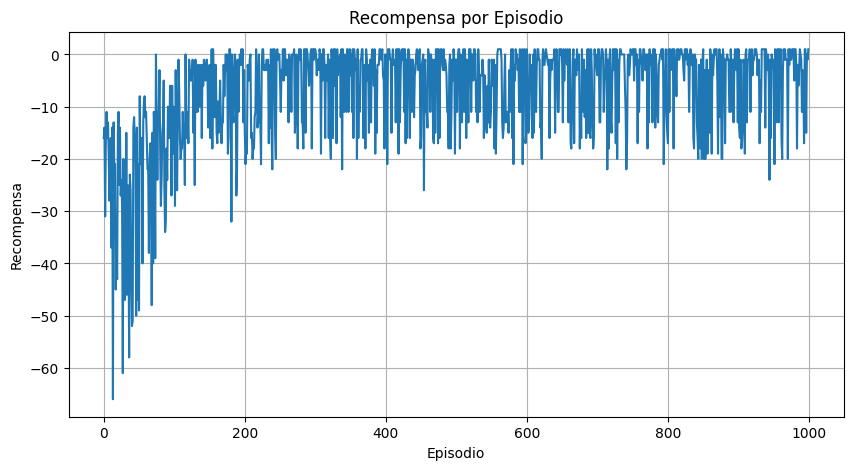

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# CONFIGURACIÓN
# ==========================================================

N = 6

ALPHA = 0.1
GAMMA = 0.9
EPSILON = 0.2

EPISODES = 1000
MAX_STEPS = 100

# ==========================================================
# ENTORNO
# ==========================================================

environment = np.zeros((N, N), dtype=int)

holes = [
    (1,1),
    (1,3),
    (3,1),
    (3,4),
    (4,3)
]

for h in holes:
    environment[h] = -1

goal = (5,5)
environment[goal] = 1

# ==========================================================
# RECOMPENSAS
# ==========================================================

rewards = np.full((N,N), -1)

for h in holes:
    rewards[h] = -10

rewards[goal] = 10

# ==========================================================
# TABLA Q
# ==========================================================

# 36 estados x 4 acciones

Q = np.zeros((N*N,4))

# ==========================================================
# FUNCIONES
# ==========================================================

def state_to_index(state):

    row,col = state # Asigna estado a celda (row, col)

    return row*N + col


def move(state, action):

    row,col = state

    if action==0: # Arriba
        row -=1

    elif action==1: # Abajo
        row +=1

    elif action==2: # Izquierda
        col -=1

    elif action==3: # Derecha
        col +=1

    row = max(0, min(N-1,row))
    col = max(0, min(N-1,col))

    return (row,col) # return (row,col) movida


def choose_action(state):

    if np.random.random() < EPSILON:

        return np.random.randint(4)

    idx = state_to_index(state)

    return np.argmax(Q[idx])


# ==========================================================
# ENTRENAMIENTO
# ==========================================================

episode_rewards = [] # Para almacenar recompensas

for episode in range(EPISODES):

    state=(0,0) # Estado inicial

    total_reward=0 # Recompensa inicial

    for step in range(MAX_STEPS):

        action = choose_action(state) # Seleccionado estado (arr, aba, izq, der)

        next_state = move(state,action) # raliza movimiento

        reward = rewards[next_state]  # obtiene recompensa

        s = state_to_index(state) # estado/camino actual
        ns = state_to_index(next_state) # nuevo estado/camino

        # Formula
        Q[s,action]=Q[s,action]+ALPHA*(
            reward
            + GAMMA*np.max(Q[ns])
            - Q[s,action]
        )

        total_reward += reward

        state = next_state

        if reward==-10 or reward==10: # Finaliza si cae en un hoyo o llega a objetivo
            break

    episode_rewards.append(total_reward)

# ==========================================================
# TABLA Q
# ==========================================================

print("\nTABLA Q FINAL\n")

actions = ["↑","↓","←","→"]

for row in range(N):

    for col in range(N):

        idx = state_to_index((row,col))

        print(f"Estado ({row},{col})")

        for a in range(4):

            print(f"   {actions[a]} : {Q[idx,a]:8.2f}")

        print()

# ==========================================================
# POLÍTICA ÓPTIMA
# ==========================================================

print("\nPOLÍTICA APRENDIDA\n")

policy=np.full((N,N)," ")

symbols=["↑","↓","←","→"]

for row in range(N):

    for col in range(N):

        if environment[row,col]==-1:

            policy[row,col]="H"

        elif environment[row,col]==1:

            policy[row,col]="G"

        else:

            idx=state_to_index((row,col))

            policy[row,col]=symbols[np.argmax(Q[idx])]

print(policy)

# ==========================================================
# RUTA APRENDIDA
# ==========================================================

print("\nRECORRIDO APRENDIDO\n")

state=(0,0)

path=[state]

for i in range(30):

    idx=state_to_index(state)

    action=np.argmax(Q[idx])

    state=move(state,action)

    path.append(state)

    if rewards[state]==10:
        break

    if rewards[state]==-10:
        break

print(path)

# ==========================================================
# GRÁFICA
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(episode_rewards)

plt.title("Recompensa por Episodio")

plt.xlabel("Episodio")

plt.ylabel("Recompensa")

plt.grid()

plt.show()